In [43]:
#Read in the version of our data with ClassyFire information (or pull it back out)
import pandas as pd
data = pd.read_csv(f"../src/data/LD50_pre-grid-search2.csv").set_index("Unnamed: 0")

In [8]:
grid_searched = ['Benzenoids',
 'Lipids and lipid-like molecules',
 'Organic acids and derivatives',
 'Organic nitrogen compounds',
 'Organoheterocyclic compounds',
 'Organic oxygen compounds',
 'Organohalogen compounds',
 'Organosulfur compounds',
 'Phenylpropanoids and polyketides',
 'unknown']

In [51]:
data.groupby('superclass').count()['LD50_LM']

superclass
Acetylides                                      5
Alkaloids and derivatives                      58
Benzenoids                                   2226
Hydrocarbons and derivatives                   22
Lignans, neolignans and related compounds       2
Lipids and lipid-like molecules               408
Nucleosides, nucleotides, and analogues        10
Organic 1,3-dipolar compounds                  23
Organic Polymers                                1
Organic acids and derivatives                 926
Organic nitrogen compounds                    442
Organic oxygen compounds                      452
Organic salts                                  33
Organohalogen compounds                       163
Organoheterocyclic compounds                 1613
Organometallic compounds                       48
Organophosphorus compounds                     55
Organosulfur compounds                        123
Phenylpropanoids and polyketides              154
unknown                                

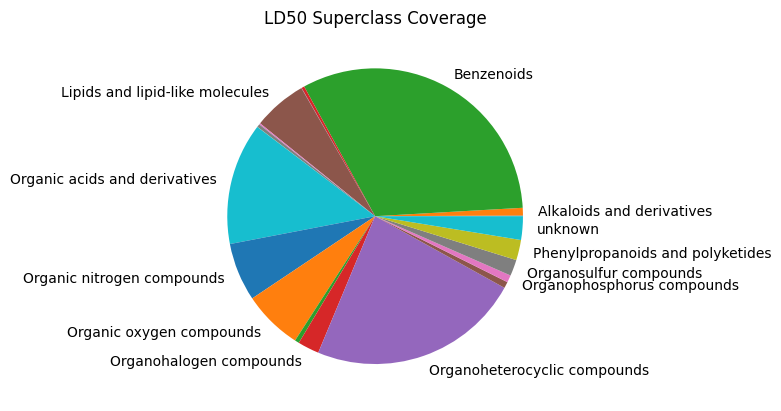

In [54]:
counts = data.groupby('superclass').count()['LD50_LM'].values
labels = data.groupby('superclass').count()['LD50_LM'].index

kept_labels = []
for i in range(len(counts)):
    if counts[i]>50:
        kept_labels.append(labels[i])
    else:
        kept_labels.append('')


import matplotlib.pyplot as plt

plt.pie(counts, labels= kept_labels, labeldistance=1.1)
plt.title('LD50 Superclass Coverage')
plt.show()

# Exploring Class Structure

In [9]:
#The Jaccard metric as it is currently assigned wants boolean values, so convert the fingerprint columns here
data[data.columns[1:-2]]=data[data.columns[1:-2]].astype("bool")

In [10]:
# View the data
data.head()

,LD50_LM,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,=C-(C#N)-C#N [dicyano] correction,Aromatic nitrogen-C-C(=S)-N struct corr.,Cyclic ketoxime(>C=N-OH) [1 olefin attach],C=N-O-sulfur(aliphatic) [iminoxy] correc,-S-N(-C(=O)-C)-C(=O)-C struct correction,-Sulfur(+4) charged halide-type,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction,superclass,class
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DTXSID5020281,-0.465339,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,Benzenoids,Benzene and substituted derivatives
DTXSID8020961,-0.734786,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,Benzenoids,Benzene and substituted derivatives
DTXSID0021834,-0.087091,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,Benzenoids,Phenols
DTXSID2044347,-1.058925,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,Organic oxygen compounds,Organooxygen compounds
DTXSID4025745,-1.022972,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,Benzenoids,Benzene and substituted derivatives


In [11]:
# Find out how many classes we have within each superclass
data.groupby('superclass')['class'].nunique()

superclass
Acetylides                                     0
Alkaloids and derivatives                     14
Benzenoids                                    17
Hydrocarbons and derivatives                   3
Lignans, neolignans and related compounds      2
Lipids and lipid-like molecules                4
Nucleosides, nucleotides, and analogues        8
Organic 1,3-dipolar compounds                  2
Organic Polymers                               1
Organic acids and derivatives                 19
Organic nitrogen compounds                     1
Organic oxygen compounds                       4
Organic salts                                  2
Organohalogen compounds                        8
Organoheterocyclic compounds                 111
Organometallic compounds                       1
Organophosphorus compounds                     5
Organosulfur compounds                        14
Phenylpropanoids and polyketides              20
unknown                                        1
Name: cla

In [12]:
#Create numerical labels for clearer use of silhouette score
n = 0
label_dict = {}
for class_name in data['superclass'].unique():
    label_dict[class_name] = n
    n += 1

In [13]:
#Place those numerical labels in the data DataFrame
data['labels'] = [label_dict[data['superclass'][i]] for i in range(0, len(data))]

C:\Users\aleary\AppData\Local\Temp\ipykernel_9276\3310534999.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['labels'] = [label_dict[data['superclass'][i]] for i in range(0, len(data))]
C:\Users\aleary\AppData\Local\Temp\ipykernel_9276\3310534999.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['labels'] = [label_dict[data['superclass'][i]] for i in range(0, len(data))]


In [14]:
#The Acetylides have only a superclass, so fill their null classes with the
#same label
data.loc[data['superclass']=='Acetylides','class'] = 'Acetylides'

In [15]:
#Check all of our modifications
data.head()

,LD50_LM,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,Aromatic nitrogen-C-C(=S)-N struct corr.,Cyclic ketoxime(>C=N-OH) [1 olefin attach],C=N-O-sulfur(aliphatic) [iminoxy] correc,-S-N(-C(=O)-C)-C(=O)-C struct correction,-Sulfur(+4) charged halide-type,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction,superclass,class,labels
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DTXSID5020281,-0.465339,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,Benzenoids,Benzene and substituted derivatives,0
DTXSID8020961,-0.734786,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,Benzenoids,Benzene and substituted derivatives,0
DTXSID0021834,-0.087091,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,Benzenoids,Phenols,0
DTXSID2044347,-1.058925,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,Organic oxygen compounds,Organooxygen compounds,1
DTXSID4025745,-1.022972,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,Benzenoids,Benzene and substituted derivatives,0


In [16]:
#Calculate silhouette scores
from sklearn.metrics import silhouette_samples

silhouettes = silhouette_samples(data.iloc[:,1:-3], data.iloc[:,-1], metric='jaccard')
print(silhouettes)

[-0.00717102 -0.00083739 -0.00492981 ... -0.00925674 -0.04547421
 -0.01680076]


In [17]:
#Add silhouette scores to the DataFrame
data = data.copy()
data['silhouettes'] = silhouettes

In [18]:
# Check average silhouette scores
data.groupby('superclass').mean(numeric_only=True)['silhouettes']

superclass
Acetylides                                   0.168333
Alkaloids and derivatives                    0.080917
Benzenoids                                  -0.001247
Hydrocarbons and derivatives                 0.033333
Lignans, neolignans and related compounds   -0.052342
Lipids and lipid-like molecules             -0.004160
Nucleosides, nucleotides, and analogues      0.220532
Organic 1,3-dipolar compounds                0.070946
Organic Polymers                             0.000000
Organic acids and derivatives               -0.036237
Organic nitrogen compounds                  -0.012461
Organic oxygen compounds                    -0.020503
Organic salts                                0.021986
Organohalogen compounds                      0.037593
Organoheterocyclic compounds                -0.021999
Organometallic compounds                     0.101828
Organophosphorus compounds                   0.083889
Organosulfur compounds                      -0.031346
Phenylpropanoids 

In [19]:
# Generate neighborhoods for every chemical
from genra.rax.skl.hybrid import GenRAPredValueHybrid
slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, None)]
estimator = GenRAPredValueHybrid(metric = 'jaccard', slices = slices, n_neighbors=8, hybrid_weights=[0,100,0,0])
estimator.fit(data.iloc[:,1:-4], data.iloc[:, 0])
neighborhoods = estimator.kneighbors( n_neighbors=8, return_distance=True)

In [20]:
# Generate optimal fingerprint neighborhoods for each chemical
opt_estimator = GenRAPredValueHybrid(metric = 'jaccard', slices = slices, n_neighbors=8, hybrid_weights=[22.58,59.59,11.08,6.75])
opt_estimator.fit(data.iloc[:,1:-4], data.iloc[:, 0])
opt_neighborhoods = opt_estimator.kneighbors( n_neighbors=8, return_distance=True)

In [21]:
#Generate optimal neighborhoods for each chemical class based on its grid search print
nickname_dict = {'benzenoids':'Benzenoids', 'organic_acids':'Organic acids and derivatives','lipids':'Lipids and lipid-like molecules', 'organic_oxygen':'Organic oxygen compounds', 'organic_nitrogen':'Organic nitrogen compounds', 'organoheterocyclic':'Organoheterocyclic compounds', 'organosulfur':'Organosulfur compounds', 'organohalogen':'Organohalogen compounds', 'phenylpropanoids':'Phenylpropanoids and polyketides', 'unknown':'unknown'}
class_nbd_dict = {}
for superclass in nickname_dict.keys():
    grid_df = pd.read_csv(f'../references/class_tests/grid_searches/{superclass}.csv').set_index("Unnamed: 0")
    pre_weights = grid_df.sort_values('mean_test_score', ascending=True).reset_index(drop = True)['param_hybrid_weights'].iloc[0].split(',')
    weights = [int(pre_weights[0][1:]), int(pre_weights[1]), int(pre_weights[2]), int(pre_weights[3][:-1])]
    class_estimator = GenRAPredValueHybrid(metric = 'jaccard', slices = slices, n_neighbors=8, hybrid_weights= weights)
    class_estimator.fit(data.iloc[:,1:-4], data.iloc[:, 0])
    class_neighborhoods = class_estimator.kneighbors(data.iloc[:,1:-4].loc[data['superclass']==nickname_dict[superclass]], n_neighbors=9, return_distance=True)
    class_nbd_dict[nickname_dict[superclass]] = {}
    class_nbd_dict[nickname_dict[superclass]]['distances'] = class_neighborhoods[0][:,1:]
    class_nbd_dict[nickname_dict[superclass]]['indices'] = class_neighborhoods[1][:,1:]

In [22]:
#The following code will set the best_neighborhoods up to be compared to the other two, as they
#are currently separated by superclass.
import numpy as np

superclass_counters = {}
for superclass in data['superclass'].unique():
    superclass_counters[superclass] = 0

best_neighbors = []
best_distances = []
for x in range(len(data)):
    superclass =  data.iloc[x].loc['superclass']
    y_class = superclass_counters[superclass]
    superclass_counters[superclass] += 1
    if superclass in class_nbd_dict.keys():
        best_neighbors.append(class_nbd_dict[superclass]['indices'][y_class])
        best_distances.append(class_nbd_dict[superclass]['distances'][y_class])
    else:
        best_neighbors.append([False for _ in range(8)])
        best_distances.append([False for _ in range(8)])
best_neighbors = np.array(best_neighbors)
best_distances = np.array(best_distances)
best_neighborhoods = (best_distances, best_neighbors)

In [23]:
import numpy as np
#Store neighborhood data in a few ways:

#neighbor_df describes each chemical's neighbors by class and distance

#class_matrix describes trends in relationships between classes

#data also gets modified here, with average neighborhood distances and frequency 
# of a chemical's own class occuring in its neighborhood

# Many of these code lines occur in threes, one for each print type tested.
neighbor_df = data.loc[:,['LD50_LM', 'superclass', 'class']].copy()
class_matrix = neighbor_df.iloc[:, 1:3].copy()

opt_neighbor_df = neighbor_df.copy()
opt_class_matrix = class_matrix.copy()

best_neighbor_df = neighbor_df.copy()
best_class_matrix = class_matrix.copy()

for x in range(0,8):
    neighbor_df[f'dist_{x}'] = ''
    neighbor_df[f'nbr_{x}'] = ''
    neighbor_df[f'LD50_{x}'] = ''

    opt_neighbor_df[f'dist_{x}'] = ''
    opt_neighbor_df[f'nbr_{x}'] = ''
    opt_neighbor_df[f'LD50_{x}'] = ''

    best_neighbor_df[f'dist_{x}'] = ''
    best_neighbor_df[f'nbr_{x}'] = ''
    best_neighbor_df[f'LD50_{x}'] = ''

for superclass in neighbor_df['superclass'].unique():
    class_matrix[superclass] = ''
    opt_class_matrix[superclass] = ''
    best_class_matrix[superclass] = ''

data['neighbors_in_class'] = ''
data['avg_nbd_dist'] = ''
data['std_nbd_dist'] = ''

data['opt_neighbors_in_class'] = ''
data['opt_avg_nbd_dist'] = ''
data['opt_std_nbd_dist'] = ''

data['best_neighbors_in_class'] = ''
data['best_avg_nbd_dist'] = ''
data['best_std_nbd_dist'] = ''
for chem_no in range(0,len(data.index)):
    chem_neighbors = neighborhoods[1][chem_no]
    chem_distances = neighborhoods[0][chem_no]

    opt_chem_neighbors = opt_neighborhoods[1][chem_no]
    opt_chem_distances = opt_neighborhoods[0][chem_no]

    best_chem_neighbors = best_neighborhoods[1][chem_no]
    best_chem_distances = best_neighborhoods[0][chem_no]

    neighbor_classes = []
    neighbor_vals = []
    neighbors_in_class = 0
    for neigh in chem_neighbors:
        neigh_class = data.iloc[neigh].loc['superclass']
        neigh_LD = data.iloc[neigh].loc['LD50_LM']
        neighbor_classes.append(neigh_class)
        neighbor_vals.append(neigh_LD)
        if neigh_class == data.iloc[chem_no].loc['superclass']:
            neighbors_in_class += 1
    data.loc[data.index[chem_no], 'neighbors_in_class'] = int(neighbors_in_class)
    data.loc[data.index[chem_no], 'avg_nbd_dist'] = np.mean(chem_distances)
    data.loc[data.index[chem_no], 'std_nbd_dist'] = np.std(chem_distances)

    opt_neighbor_classes = []
    opt_neighbor_vals = []
    opt_neighbors_in_class = 0
    for neigh in opt_chem_neighbors:
        opt_neigh_class = data.iloc[neigh].loc['superclass']
        opt_neigh_LD = data.iloc[neigh].loc['LD50_LM']
        opt_neighbor_classes.append(opt_neigh_class)
        opt_neighbor_vals.append(opt_neigh_LD)
        if opt_neigh_class == data.iloc[chem_no].loc['superclass']:
            opt_neighbors_in_class += 1
    data.loc[data.index[chem_no], 'opt_neighbors_in_class'] = int(opt_neighbors_in_class)
    data.loc[data.index[chem_no], 'opt_avg_nbd_dist'] = np.mean(opt_chem_distances)
    data.loc[data.index[chem_no], 'opt_std_nbd_dist'] = np.std(opt_chem_distances)

    best_neighbor_classes = []
    best_neighbor_vals = []
    best_neighbors_in_class = 0
    for neigh in best_chem_neighbors:
        best_neigh_class = data.iloc[neigh].loc['superclass']
        best_neigh_LD = data.iloc[neigh].loc['LD50_LM']
        best_neighbor_classes.append(best_neigh_class)
        best_neighbor_vals.append(opt_neigh_LD)
        if best_neigh_class == data.iloc[chem_no].loc['superclass']:
            best_neighbors_in_class += 1
    data.loc[data.index[chem_no], 'best_neighbors_in_class'] = int(best_neighbors_in_class)
    data.loc[data.index[chem_no], 'best_avg_nbd_dist'] = np.mean(best_chem_distances)
    data.loc[data.index[chem_no], 'best_std_nbd_dist'] = np.std(best_chem_distances)

    

    for x in range(0,8):
        neighbor_df.loc[neighbor_df.index[chem_no], f'nbr_{x}'] = neighbor_classes[x]
        neighbor_df.loc[neighbor_df.index[chem_no], f'dist_{x}'] = chem_distances[x]
        neighbor_df.loc[neighbor_df.index[chem_no], f'LD50_{x}'] = neighbor_vals[x]

        opt_neighbor_df.loc[opt_neighbor_df.index[chem_no], f'nbr_{x}'] = opt_neighbor_classes[x]
        opt_neighbor_df.loc[opt_neighbor_df.index[chem_no], f'dist_{x}'] = opt_chem_distances[x]
        opt_neighbor_df.loc[opt_neighbor_df.index[chem_no], f'LD50_{x}'] = opt_neighbor_vals[x]

        best_neighbor_df.loc[best_neighbor_df.index[chem_no], f'nbr_{x}'] = best_neighbor_classes[x]
        best_neighbor_df.loc[best_neighbor_df.index[chem_no], f'dist_{x}'] = best_chem_distances[x]
        best_neighbor_df.loc[best_neighbor_df.index[chem_no], f'LD50_{x}'] = best_neighbor_vals[x]
    for superclass in data['superclass'].unique():
        class_matrix.loc[class_matrix.index[chem_no], superclass] = neighbor_classes.count(superclass)
        class_matrix.loc[class_matrix.index[chem_no], superclass] = opt_neighbor_classes.count(superclass)
        class_matrix.loc[class_matrix.index[chem_no], superclass] = best_neighbor_classes.count(superclass)

In [20]:
#The above creates some string objects in columns, so we change those back to 
# numerical columns in the next two blocks
neighbor_df = neighbor_df.astype({'dist_0':'float', 'LD50_0':'float',
'dist_1':'float', 'LD50_1':'float',
'dist_2':'float', 'LD50_2':'float',
'dist_3':'float', 'LD50_3':'float',
'dist_4':'float', 'LD50_4':'float',
'dist_5':'float', 'LD50_5':'float',
'dist_6':'float', 'LD50_6':'float',
'dist_7':'float', 'LD50_7':'float'})

opt_neighbor_df = opt_neighbor_df.astype({'dist_0':'float', 'LD50_0':'float',
'dist_1':'float', 'LD50_1':'float',
'dist_2':'float', 'LD50_2':'float',
'dist_3':'float', 'LD50_3':'float',
'dist_4':'float', 'LD50_4':'float',
'dist_5':'float', 'LD50_5':'float',
'dist_6':'float', 'LD50_6':'float',
'dist_7':'float', 'LD50_7':'float'})

best_neighbor_df = best_neighbor_df.astype({'dist_0':'float', 'LD50_0':'float',
'dist_1':'float', 'LD50_1':'float',
'dist_2':'float', 'LD50_2':'float',
'dist_3':'float', 'LD50_3':'float',
'dist_4':'float', 'LD50_4':'float',
'dist_5':'float', 'LD50_5':'float',
'dist_6':'float', 'LD50_6':'float',
'dist_7':'float', 'LD50_7':'float'})

In [31]:
class_matrix = class_matrix.astype({'Benzenoids':'float',
'Organic oxygen compounds':'float',
'Organic nitrogen compounds':'float',
'Hydrocarbons and derivatives':'float',
'Organoheterocyclic compounds':'float',
'unknown':'float',
'Organic acids and derivatives':'float',
'Organometallic compounds':'float',
'Lipids and lipid-like molecules':'float',
'Alkaloids and derivatives':'float',
'Phenylpropanoids and polyketides':'float',
'Organohalogen compounds':'float',
'Organic salts':'float',
'Organophosphorus compounds':'float',
'Organosulfur compounds':'float',
'Acetylides':'float',
'Organic 1,3-dipolar compounds':'float',
'Nucleosides, nucleotides, and analogues':'float',
'Lignans, neolignans and related compounds':'float',
'Organic Polymers':'float',})

opt_class_matrix = opt_class_matrix.astype({'Benzenoids':'float',
'Organic oxygen compounds':'float',
'Organic nitrogen compounds':'float',
'Hydrocarbons and derivatives':'float',
'Organoheterocyclic compounds':'float',
'unknown':'float',
'Organic acids and derivatives':'float',
'Organometallic compounds':'float',
'Lipids and lipid-like molecules':'float',
'Alkaloids and derivatives':'float',
'Phenylpropanoids and polyketides':'float',
'Organohalogen compounds':'float',
'Organic salts':'float',
'Organophosphorus compounds':'float',
'Organosulfur compounds':'float',
'Acetylides':'float',
'Organic 1,3-dipolar compounds':'float',
'Nucleosides, nucleotides, and analogues':'float',
'Lignans, neolignans and related compounds':'float',
'Organic Polymers':'float',})

best_class_matrix = best_class_matrix.replace('', '0')
best_class_matrix = best_class_matrix.astype({'Benzenoids':'float',
'Organic oxygen compounds':'float',
'Organic nitrogen compounds':'float',
'Hydrocarbons and derivatives':'float',
'Organoheterocyclic compounds':'float',
'unknown':'float',
'Organic acids and derivatives':'float',
'Organometallic compounds':'float',
'Lipids and lipid-like molecules':'float',
'Alkaloids and derivatives':'float',
'Phenylpropanoids and polyketides':'float',
'Organohalogen compounds':'float',
'Organic salts':'float',
'Organophosphorus compounds':'float',
'Organosulfur compounds':'float',
'Acetylides':'float',
'Organic 1,3-dipolar compounds':'float',
'Nucleosides, nucleotides, and analogues':'float',
'Lignans, neolignans and related compounds':'float',
'Organic Polymers':'float',})

In [32]:
neighbor_df.to_csv("../references/class_tests/backup_dfs/neighbor_df.csv")
opt_neighbor_df.to_csv("../references/class_tests/backup_dfs/opt_neighbor_df.csv")
best_neighbor_df.to_csv("../references/class_tests/backup_dfs/best_neighbor_df.csv")

class_matrix.to_csv("../references/class_tests/backup_dfs/class_matrix.csv")
opt_class_matrix.to_csv("../references/class_tests/backup_dfs/opt_class_matrix.csv")
best_class_matrix.to_csv("../references/class_tests/backup_dfs/best_class_matrix.csv")

In [11]:
neighbor_df.drop(columns = {'LD50_LM', 'superclass', 'class'})


,Unnamed: 0,dist_0,nbr_0,LD50_0,dist_1,nbr_1,LD50_1,dist_2,nbr_2,LD50_2,...,LD50_4,dist_5,nbr_5,LD50_5,dist_6,nbr_6,LD50_6,dist_7,nbr_7,LD50_7
0,DTXSID5020281,0.482759,Benzenoids,-0.087091,0.531250,Benzenoids,-1.022972,0.533333,Benzenoids,-0.734786,...,-1.174596,0.545455,Benzenoids,-1.479704,0.548387,Organosulfur compounds,-0.731853,0.558824,Benzenoids,-0.587409
1,DTXSID8020961,0.533333,Benzenoids,-0.465339,0.533333,Benzenoids,-0.087091,0.533333,unknown,-0.298076,...,-0.457143,0.548387,Organosulfur compounds,-0.731853,0.562500,Benzenoids,-1.492773,0.575758,Benzenoids,-1.176648
2,DTXSID0021834,0.482759,Benzenoids,-0.465339,0.531250,Benzenoids,-1.069228,0.533333,Benzenoids,-0.734786,...,-1.174596,0.545455,Benzenoids,-1.479704,0.545455,Benzenoids,-0.457143,0.548387,Organosulfur compounds,-0.731853
3,DTXSID2044347,0.513514,Benzenoids,-1.053868,0.520000,Benzenoids,-1.415901,0.526316,Benzenoids,-1.372213,...,-1.307061,0.562500,Organic oxygen compounds,-0.450058,0.571429,Organic oxygen compounds,-0.941555,0.580645,Benzenoids,-1.110212
4,DTXSID4025745,0.531250,Benzenoids,-0.465339,0.538462,Benzenoids,-0.864048,0.545455,Organosulfur compounds,-0.731853,...,-0.083195,0.575758,Benzenoids,-0.087091,0.575758,Benzenoids,-0.734786,0.575758,unknown,-0.298076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6938,DTXSID3044752,0.518519,Organic acids and derivatives,-0.306295,0.535714,Organic acids and derivatives,-0.113436,0.536585,Phenylpropanoids and polyketides,-0.907164,...,-1.014437,0.606061,Organic acids and derivatives,0.255806,0.628571,Lipids and lipid-like molecules,-0.290150,0.638889,Organic acids and derivatives,-0.106769
6939,DTXSID80244288,0.695652,Organophosphorus compounds,-0.219125,0.714286,Organophosphorus compounds,-0.484097,0.750000,Organoheterocyclic compounds,-0.910899,...,2.076557,0.758621,Organophosphorus compounds,1.103383,0.769231,Organosulfur compounds,-1.181138,0.771429,Organophosphorus compounds,0.298261
6940,DTXSID0022143,0.344828,Organic acids and derivatives,-1.581963,0.454545,Organic acids and derivatives,-1.618494,0.517241,Organic acids and derivatives,-0.902582,...,-0.246254,0.568182,Organic acids and derivatives,-1.314763,0.575758,Organic acids and derivatives,-0.067086,0.588235,Organic acids and derivatives,-0.286896
6941,DTXSID6020303,0.555556,Organic nitrogen compounds,-1.386531,0.571429,Organic nitrogen compounds,0.540976,0.631579,Organic nitrogen compounds,0.113898,...,-0.902107,0.703704,Organic nitrogen compounds,-0.148063,0.703704,Organic nitrogen compounds,-0.304992,0.714286,Organohalogen compounds,-0.830659


In [23]:
#Here we get a sense of the "average neighborhood" for each chemical superclass
class_matrix.groupby('superclass').mean(numeric_only = True).loc[['Benzenoids',
 'Lipids and lipid-like molecules',
 'Organic acids and derivatives',
 'Organic nitrogen compounds',
 'Organic oxygen compounds',
 'Organohalogen compounds',
 'Organoheterocyclic compounds',
 'Organosulfur compounds',
 'Phenylpropanoids and polyketides',
'unknown']]

,Benzenoids,Organic oxygen compounds,Organic nitrogen compounds,Hydrocarbons and derivatives,Organoheterocyclic compounds,unknown,Organic acids and derivatives,Organometallic compounds,Lipids and lipid-like molecules,Alkaloids and derivatives,Phenylpropanoids and polyketides,Organohalogen compounds,Organic salts,Organophosphorus compounds,Organosulfur compounds,Acetylides,"Organic 1,3-dipolar compounds","Nucleosides, nucleotides, and analogues","Lignans, neolignans and related compounds",Organic Polymers
superclass,,,,,,,,,,,,,,,,,,,,
Benzenoids,6.868823,0.095687,0.088949,0.000449,0.368374,0.151393,0.163073,0.007188,0.079964,0.015723,0.117700,0.007188,0.000898,0.008985,0.022013,0.000000,0.000898,0.000000,0.002695,0.00000
Lipids and lipid-like molecules,0.490196,0.490196,0.125000,0.029412,0.166667,0.029412,0.669118,0.000000,5.757353,0.022059,0.053922,0.142157,0.000000,0.002451,0.019608,0.000000,0.002451,0.000000,0.000000,0.00000
Organic acids and derivatives,0.468683,0.286177,0.234341,0.012959,0.400648,0.210583,5.462203,0.015119,0.561555,0.023758,0.033477,0.090713,0.020518,0.086393,0.069114,0.000000,0.003240,0.015119,0.001080,0.00432
Organic nitrogen compounds,0.515837,0.298643,5.488688,0.045249,0.450226,0.203620,0.445701,0.004525,0.160633,0.000000,0.004525,0.138009,0.033937,0.024887,0.151584,0.018100,0.015837,0.000000,0.000000,0.00000
Organic oxygen compounds,0.657080,4.938053,0.207965,0.055310,0.460177,0.161504,0.526549,0.026549,0.586283,0.022124,0.077434,0.168142,0.015487,0.028761,0.035398,0.015487,0.011062,0.006637,0.000000,0.00000
Organohalogen compounds,0.147239,0.496933,0.171779,0.030675,0.171779,0.049080,0.386503,0.000000,0.386503,0.000000,0.000000,5.969325,0.006135,0.012270,0.110429,0.000000,0.061350,0.000000,0.000000,0.00000
Organoheterocyclic compounds,1.021699,0.146931,0.172970,0.011779,5.848109,0.215747,0.266584,0.005580,0.079975,0.044017,0.074396,0.043397,0.004340,0.006820,0.035338,0.000000,0.007440,0.014259,0.000620,0.00000
Organosulfur compounds,0.951220,0.536585,1.252033,0.170732,0.487805,0.154472,0.609756,0.097561,0.211382,0.000000,0.000000,0.349593,0.113821,0.308943,2.731707,0.008130,0.016260,0.000000,0.000000,0.00000
Phenylpropanoids and polyketides,2.123377,0.214286,0.019481,0.019481,0.629870,0.344156,0.240260,0.000000,0.181818,0.019481,4.181818,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025974,0.00000


In [24]:
#More repairs to data type
data = data.astype({'neighbors_in_class': 'int', 'avg_nbd_dist':'float', \
    'std_nbd_dist':'float','opt_neighbors_in_class': 'int', \
    'opt_avg_nbd_dist':'float', 'opt_std_nbd_dist':'float',\
    'best_neighbors_in_class': 'int', 'best_avg_nbd_dist':'float',\
    'best_std_nbd_dist':'float'})

In [26]:
data.to_csv('../references/class_tests/backup_dfs/data.csv')

In [2]:
import pandas as pd
data = pd.read_csv('../references/class_tests/backup_dfs/data.csv')

In [3]:
# This subview focuses in on the chemical classes which we've tested most extensively
subview = data.loc[[data['superclass'].iloc[i] in ['Benzenoids',
 'Lipids and lipid-like molecules',
 'Organic acids and derivatives',
 'Organic nitrogen compounds',
 'Organoheterocyclic compounds',
 'Organic oxygen compounds',
 'Organohalogen compounds',
 'Organosulfur compounds',
 'Phenylpropanoids and polyketides',
 'unknown'] for i in range(0,len(data))]]



In [4]:
#On average, how many of this class' neighbors are also in this class?
subview.groupby('superclass').mean(numeric_only=True)['neighbors_in_class']

superclass
Benzenoids                          6.772686
Lipids and lipid-like molecules     5.063725
Organic acids and derivatives       5.354212
Organic nitrogen compounds          4.816742
Organic oxygen compounds            4.376106
Organohalogen compounds             4.957055
Organoheterocyclic compounds        5.403596
Organosulfur compounds              2.317073
Phenylpropanoids and polyketides    3.870130
unknown                             0.273743
Name: neighbors_in_class, dtype: float64

In [5]:
#How close are neighbors to chemicals of this class, on average?
subview.groupby('superclass').mean(numeric_only=True)['avg_nbd_dist']

superclass
Benzenoids                          0.601947
Lipids and lipid-like molecules     0.577943
Organic acids and derivatives       0.584311
Organic nitrogen compounds          0.602097
Organic oxygen compounds            0.596432
Organohalogen compounds             0.638939
Organoheterocyclic compounds        0.647415
Organosulfur compounds              0.659157
Phenylpropanoids and polyketides    0.607840
unknown                             0.613805
Name: avg_nbd_dist, dtype: float64

In [33]:
# How big are the differences in distances across neighborhoods in this class?
subview.groupby('superclass').mean(numeric_only=True)['std_nbd_dist']

superclass
Benzenoids                          0.073575
Lipids and lipid-like molecules     0.091812
Organic acids and derivatives       0.075082
Organic nitrogen compounds          0.083047
Organic oxygen compounds            0.077544
Organohalogen compounds             0.082166
Organoheterocyclic compounds        0.079401
Organosulfur compounds              0.062444
Phenylpropanoids and polyketides    0.108054
unknown                             0.089527
Name: std_nbd_dist, dtype: float64

In [35]:
#What are the average silhouette scores for this class?
subview.groupby('superclass').mean(numeric_only=True)['silhouettes']

superclass
Benzenoids                         -0.001247
Lipids and lipid-like molecules    -0.004160
Organic acids and derivatives      -0.036237
Organic nitrogen compounds         -0.012461
Organic oxygen compounds           -0.020503
Organohalogen compounds             0.037593
Organoheterocyclic compounds       -0.021999
Organosulfur compounds             -0.031346
Phenylpropanoids and polyketides    0.016929
unknown                            -0.044198
Name: silhouettes, dtype: float64

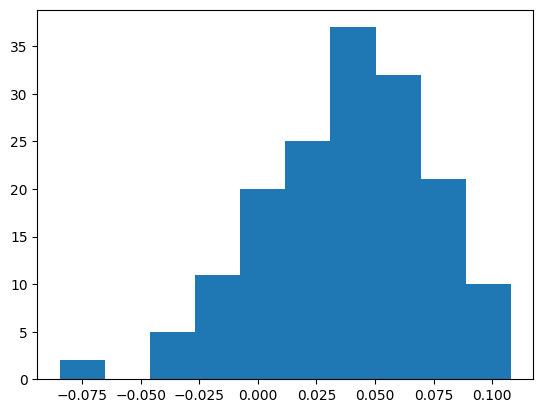

In [36]:
import matplotlib.pyplot as plt

plt.hist(subview.loc[subview['superclass']=='Organohalogen compounds']['silhouettes'])
plt.show()

In [37]:
#Since this will not show here properly, calculate how many neighborhoods 
#contain each number of a chemical's own class and save out as a csv for viewing
subview.groupby('superclass')['neighbors_in_class'].value_counts().to_csv('neighbor_counts.csv')

In [38]:
#View the average distance by neighbor number by class
neighbor_df.groupby('superclass').mean(numeric_only = True)[[f'dist_{x}' for x in range(0,8)]]

,dist_0,dist_1,dist_2,dist_3,dist_4,dist_5,dist_6,dist_7
superclass,,,,,,,,
Acetylides,0.613397,0.623397,0.662330,0.693434,0.714636,0.732252,0.757755,0.762549
Alkaloids and derivatives,0.366194,0.533053,0.639284,0.664676,0.692103,0.730396,0.741998,0.753520
Benzenoids,0.451991,0.545429,0.587078,0.613894,0.633570,0.649467,0.662106,0.672041
Hydrocarbons and derivatives,0.535063,0.694754,0.729055,0.737365,0.751632,0.757273,0.770103,0.777755
"Lignans, neolignans and related compounds",0.666031,0.726111,0.745994,0.760464,0.764000,0.773299,0.778028,0.782763
Lipids and lipid-like molecules,0.390989,0.508416,0.561849,0.592733,0.619108,0.638049,0.649465,0.662936
"Nucleosides, nucleotides, and analogues",0.552699,0.670500,0.723580,0.752096,0.790468,0.808500,0.818553,0.826120
"Organic 1,3-dipolar compounds",0.518044,0.625542,0.664230,0.679068,0.695886,0.702416,0.710270,0.716827
Organic Polymers,0.530612,0.600000,0.763636,0.767857,0.779661,0.785714,0.785714,0.787234


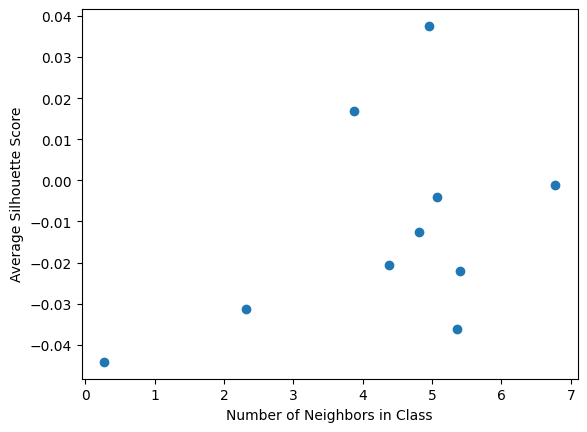

In [39]:
import matplotlib.pyplot as plt

#A preliminary graph to check for relationships between variables we just plotted
plt.scatter(subview.groupby('superclass').mean(numeric_only=True)['neighbors_in_class'].values,subview.groupby('superclass').mean(numeric_only=True)['silhouettes'].values)
plt.xlabel("Number of Neighbors in Class")
plt.ylabel("Average Silhouette Score")
plt.show()

In [70]:
# Examine how much neighborhoods overlap between fingerprints, check: Are different fingerprints using
# the same neighbors, just with different distances?
def countSharedNeighbors(neighborhoods1, neighborhoods2):
    shared_neighbors = []
    for i in range(len(neighborhoods1[1])):
        shared_neighbors.append(len(set(neighborhoods1[1][i]).intersection(set(neighborhoods2[1][i]))))
    return shared_neighbors

opt_mor_ints = countSharedNeighbors(neighborhoods, opt_neighborhoods)
opt_best_ints = countSharedNeighbors(opt_neighborhoods, best_neighborhoods)
mor_best_ints = countSharedNeighbors(neighborhoods, best_neighborhoods)

from numpy import mean
from itertools import compress
index_list = [data['superclass'].iloc[i] in grid_searched for i in range(len(data))]
testable_opt_best = list(compress(opt_best_ints, index_list))
testable_mor_best = list(compress(mor_best_ints, index_list))
mean(opt_mor_ints), mean(testable_opt_best), mean(testable_mor_best)


(5.7483796629698976, 6.6094825007478315, 4.841908465450194)

# Comparing Class Structure with Performance

In [39]:
#Read in performance data for our 10 subview superclasses
performance_df = pd.read_csv("../references/class_tests/comparisons.csv").set_index("Unnamed: 0")
performance_df.index=[0,1,2,3,6,4,5,7,8,9]
performance_df = performance_df.sort_index()
performance_df.head(10)

,superclass,class_size,morgan_r2,optimum_r2,best_in_class_r2,morgan_rmse,optimum_rmse,best_in_class_rmse,best_weight
0,Benzenoids,2226,0.428965,0.476998,0.477891,0.558709,0.534695,0.534238,"[40, 50, 0, 10]"
1,Lipids and lipid-like molecules,408,0.620973,0.640059,0.619543,0.597667,0.582424,0.598793,"[30, 0, 70, 0]"
2,Organic acids and derivatives,926,0.539993,0.582229,0.593294,0.733486,0.699003,0.689684,"[30, 40, 20, 10]"
3,Organic nitrogen compounds,442,0.318791,0.362185,0.348189,0.601136,0.581674,0.588022,"[70, 20, 10, 0]"
4,Organic oxygen compounds,452,0.469880,0.483612,0.487414,0.565377,0.558006,0.555948,"[25, 75, 0, 0]"
5,Organohalogen compounds,163,0.096536,0.137320,0.117353,0.728301,0.711673,0.719861,"[45, 50, 5, 0]"
6,Organoheterocyclic compounds,1613,0.592499,0.589885,0.582417,0.577776,0.579626,0.584879,"[30, 40, 20, 10]"
7,Organosulfur compounds,123,0.428639,0.428963,0.458131,0.752849,0.752635,0.733162,"[0, 20, 15, 65]"
8,Phenylpropanoids and polyketides,154,0.467259,0.423852,0.454083,0.640873,0.666470,0.648749,"[10, 60, 0, 30]"
9,unknown,179,0.280511,0.299691,0.322998,0.706309,0.696831,0.685138,"[30, 30, 30, 10]"


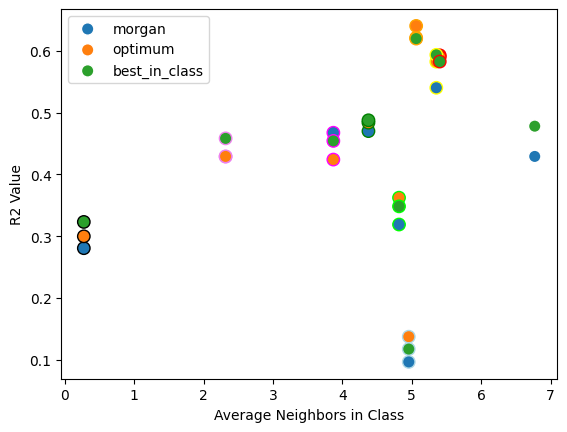

In [73]:
import matplotlib.pyplot as plt

#Plot Average neighbors in the same class as the tested chemical vs. average performance
fig, ax = plt.subplots()

for print_name in ['morgan', 'optimum', 'best_in_class']:
    coloring = ['white', 'orange', 'yellow', 'lime', 'green', 'lightblue', 'red', 'violet', 'magenta', 'black']
    ax.scatter(x =subview.groupby('superclass').mean(numeric_only=True)['neighbors_in_class'].values,y= performance_df[f'{print_name}_r2'], label = print_name, edgecolors = coloring, s = 80 )

plt.xlabel("Average Neighbors in Class")
plt.ylabel("R2 Value")
plt.legend()
plt.show()


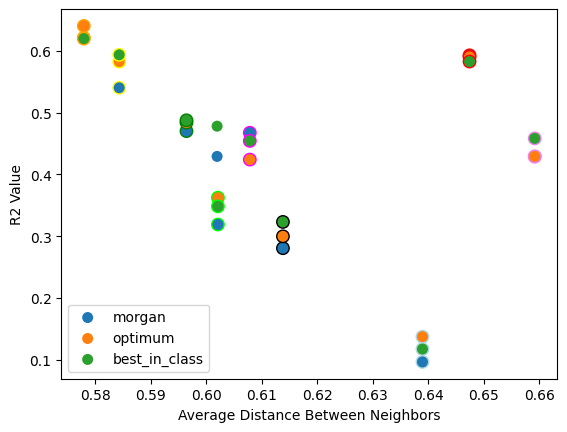

In [26]:
fig, ax = plt.subplots()

#Plot average distance between neighbors vs. average performance
for print_name in ['morgan', 'optimum', 'best_in_class']:
    coloring = ['white', 'orange', 'yellow', 'lime', 'green', 'lightblue', 'red', 'violet', 'magenta', 'black']
    ax.scatter(x =subview.groupby('superclass').mean(numeric_only=True)['avg_nbd_dist'].values,y= performance_df[f'{print_name}_r2'], label = print_name,edgecolors = coloring, s = 80)

plt.xlabel("Average Distance Between Neighbors")
plt.ylabel("R2 Value")
plt.legend()
plt.show()

In [237]:
#Create rankings on performance_df for how fingerprints performed comparitively
ranks = np.zeros((len(performance_df['superclass']),3))
i = 0
for superclass in performance_df['superclass']:
    df = performance_df.set_index('superclass')
    mor = df.loc[superclass,'morgan_r2']
    opt = df.loc[superclass,'optimum_r2']
    best = df.loc[superclass,'best_in_class_r2']
    set_list = [mor, opt, best]
    ranked_list = sorted(set_list, reverse = True)
    ranks_list = [ranked_list.index(i)+1 for i in set_list]
    ranks[i] = ranks_list
    i+= 1
performance_df['morgan_rank'] = ranks[:,0]
performance_df['optimum_rank'] = ranks[:,1]
performance_df['best_in_class_rank'] = ranks[:,2]

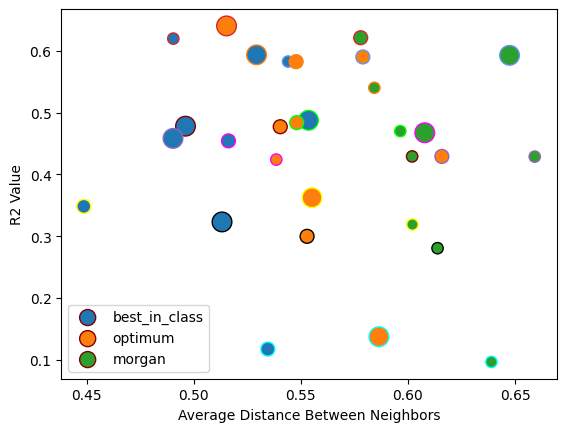

In [239]:
#Import our dependencies
import matplotlib.pyplot as plt
import numpy as np

#Plot average distance between neighbors vs. average performance 
# Unlike the previous graph, this pulls the distance calculated using the
# print plotted

#Set up the subplots, as we will be pasting onto the same graph repeatedly
fig, ax = plt.subplots()

#Set the bottom of each bar to zero. Changing the value of this variable will allow for
#traditional stacked bar graphs, but is not necessary here
bottom = np.zeros(10)

#Create a color dictionary so that bars are colored based on the fingerprint we are plotting a value for
colors = {'Benzenoids':'maroon', 'Lipids and lipid-like molecules':'tab:red',
       'Organic acids and derivatives':'tab:orange', 'Organic nitrogen compounds':'yellow',
       'Organic oxygen compounds':'lime', 'Organohalogen compounds':'cyan',
       'Organoheterocyclic compounds':'cornflowerblue', 'Organosulfur compounds':'tab:purple',
       'Phenylpropanoids and polyketides':'magenta', 'unknown':'black'}

#We will plot each print's data one at a time
for print_type in ['best_', 'opt_', '']:
    print_dict = {'best_':'best_in_class', 'opt_':'optimum', '':'morgan'}
    print_name = print_dict[print_type]
    x = subview.groupby('superclass').mean(numeric_only=True)[f'{print_type}avg_nbd_dist'].values
    y = performance_df[f'{print_name}_r2']
    labels = subview.groupby('superclass').mean(numeric_only=True)[f'{print_type}avg_nbd_dist'].index
    coloring = []
    for name in labels:
        coloring.append(colors[name])
    p = ax.scatter(x, y, \
                label = print_name, edgecolors = coloring, s=200/performance_df[f'{print_name}_rank'])
    

#Set titles and show legend
plt.xlabel("Average Distance Between Neighbors")
plt.ylabel("R2 Value")
plt.legend()
plt.show()


#Show the graph
plt.show()

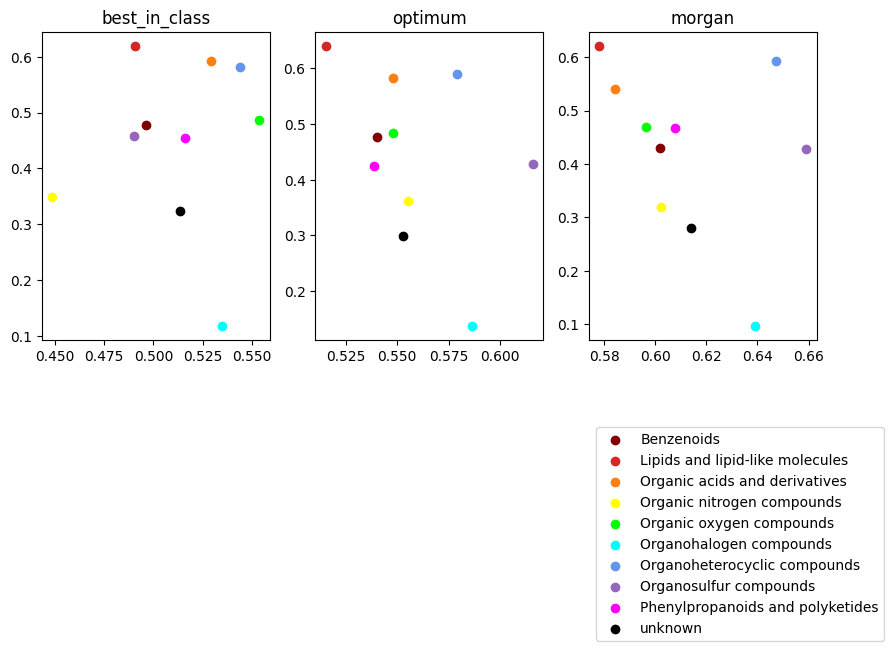

In [294]:

#Clean up the previous graph by separating some pieces

#Set up the subplots, as we will be pasting onto the same graph repeatedly
fig, axs = plt.subplots(1,3, sharex= False, sharey=False, figsize = (10,4))

#Set the bottom of each bar to zero. Changing the value of this variable will allow for
#traditional stacked bar graphs, but is not necessary here
bottom = np.zeros(10)

#Create a color dictionary so that bars are colored based on the fingerprint we are plotting a value for
colors = {'Benzenoids':'maroon', 'Lipids and lipid-like molecules':'tab:red',
       'Organic acids and derivatives':'tab:orange', 'Organic nitrogen compounds':'yellow',
       'Organic oxygen compounds':'lime', 'Organohalogen compounds':'cyan',
       'Organoheterocyclic compounds':'cornflowerblue', 'Organosulfur compounds':'tab:purple',
       'Phenylpropanoids and polyketides':'magenta', 'unknown':'black'}

#This time each print will be on a different axis
i = 0
for superclass in performance_df.superclass:
    j = 0
    for print_type in ['best_', 'opt_', '']:
        print_dict = {'best_':'best_in_class', 'opt_':'optimum', '':'morgan'}
        print_name = print_dict[print_type]
        x = subview.groupby('superclass').mean(numeric_only=True).loc[superclass,f'{print_type}avg_nbd_dist']
        y = performance_df.set_index('superclass').loc[superclass,f'{print_name}_r2']
        labels = subview.groupby('superclass').mean(numeric_only=True)[f'{print_type}avg_nbd_dist'].index
        color = colors[superclass]
        p = axs[j].scatter(x, y, c = color, label = superclass)
        if i == 0:
            axs[j].set_title(print_name)
        elif i == len(performance_df.superclass)-1:
            pre_x = subview.groupby('superclass').mean(numeric_only=True)[f'{print_type}avg_nbd_dist'].values
            pre_y = performance_df.set_index('superclass')[f'{print_name}_r2']

            #This would plot the best fit line, but the outliers here drastically reduce the utility of
            #that line, so to use such predictions we would need more complex code excluding those points
            # m,b = np.polyfit(pre_x,pre_y,1)
            # axs[j].plot(pre_x,m*pre_x+b, c = 'black')
            # axs[j].annotate(f'R2 = {round(1-sum((m*pre_x+b-pre_y)**2)/sum((pre_y - mean(pre_y))**2), 4)}', \
            #      xy = (min(pre_x), min(pre_y)))
        j += 1
    i += 1
    


#Show legend
axs[2].legend(performance_df['superclass'].values, bbox_to_anchor = (0,-1), loc = 'lower left')

#Show the graph
plt.show()

In [56]:
x1.reshape(1,-1)[0]

array([0.60194696, 0.57794328, 0.58431144, 0.60209734, 0.59643187,
       0.63893923, 0.60784021, 0.61380494])

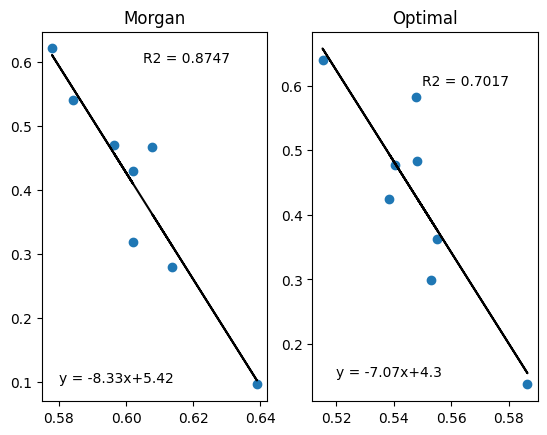

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

fig, axs = plt.subplots(1,2)

problem_set = ['Organoheterocyclic compounds', 'Organosulfur compounds']

x1 = subview.loc[[subview['superclass'].iloc[i] not in problem_set for i in range(len(subview))],['avg_nbd_dist','superclass']].groupby('superclass').mean(numeric_only=True).values
y1 = performance_df.loc[[performance_df['superclass'][i] not in problem_set for i in range(len(performance_df))],f'morgan_r2']
axs[0].scatter(x1,y1)
x1 = x1.reshape(1,-1)[0]
m1, b1 = np.polyfit(x1,y1,1)
axs[0].plot(x1, m1*x1+b1, c = 'black')
axs[0].annotate(f'y = {round(m1,2)}x+{round(b1,2)}',xy =(0.58, 0.1))
axs[0].annotate(f'R2 = {round(r2_score(m1*x1+b1, y1),4)}', xy = (0.605, 0.6))
axs[0].set_title("Morgan")

x2 = subview.loc[[subview['superclass'].iloc[i] not in problem_set for i in range(len(subview))],['opt_avg_nbd_dist','superclass']].groupby('superclass').mean(numeric_only=True).values
y2 = performance_df.loc[[performance_df['superclass'][i] not in problem_set for i in range(len(performance_df))],f'optimum_r2']
axs[1].scatter(x2,y2)
x2 = x2.reshape(1,-1)[0]
m2, b2 = np.polyfit(x2,y2,1)
axs[1].plot(x2, m2*x2+b2, c = 'black')
axs[1].annotate(f'y = {round(m2,2)}x+{round(b2,2)}',xy =(0.52, 0.15))
axs[1].annotate(f'R2 = {round(r2_score(m2*x2+b2, y2),4)}', xy = (0.55, 0.6))
axs[1].set_title("Optimal")
plt.show()

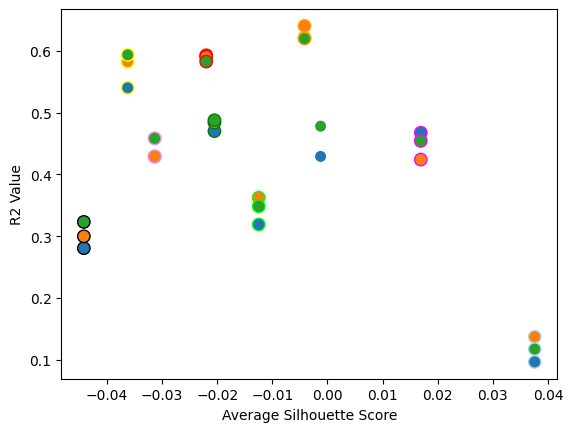

In [44]:
#Plot average silhouettes vs. average performance
fig, ax = plt.subplots()

for print_name in ['morgan', 'optimum', 'best_in_class']:
    coloring = ['white', 'orange', 'yellow', 'lime', 'green', 'lightblue', 'red', 'violet', 'magenta', 'black']
    ax.scatter(x =subview.groupby('superclass').mean(numeric_only=True)['silhouettes'].values,y= performance_df[f'{print_name}_r2'].values, label = print_name,edgecolors = coloring, s = 80)

plt.xlabel("Average Silhouette Score")
plt.ylabel("R2 Value")
plt.show()

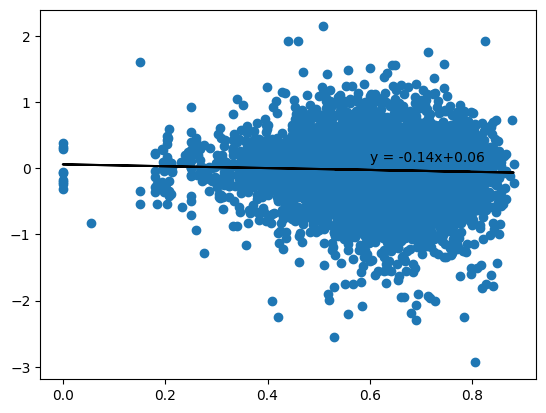

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np


#Look at the relationship between average neighborhood distance and accuracy 
# of predictions
estimator.fit(data.iloc[:,1:-7], data.iloc[:,0])
y_preds = estimator.predict(data.iloc[:, 1:-7])
m,b = np.polyfit(data['avg_nbd_dist'], (y_preds  - data.iloc[:,0].values), 1)
plt.plot(data['avg_nbd_dist'], m*data['avg_nbd_dist']+b, c = 'black')
plt.annotate(f'y = {round(m,2)}x+{round(b,2)}',xy = (0.6,0.1))
plt.scatter(data['avg_nbd_dist'], (y_preds  - data.iloc[:,0].values) )
plt.show()

In [74]:
print(f"The r2 score for the relation between average neighborhood distance \n and error of prediction is \
{1-sum((data.iloc[:,0].values - y_preds)**2)/sum((data.iloc[:,0].values - mean(data.iloc[:,0].values))**2)}")

The r2 score for the relation between average neighborhood distance 
 and error of prediction is 0.7567882229740998


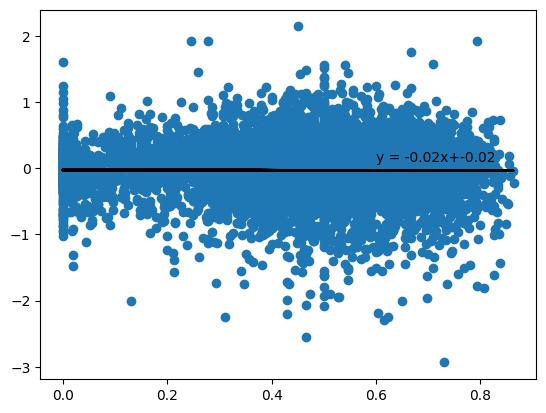

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np


#Look at the relationship between average neighborhood distance and accuracy 
# of predictions

m,b = np.polyfit(neighbor_df['dist_0'], (y_preds  - data.iloc[:,0].values), 1)
plt.plot(neighbor_df['dist_0'], m*data['avg_nbd_dist']+b, c = 'black')
plt.annotate(f'y = {round(m,2)}x+{round(b,2)}',xy = (0.6,0.1))
plt.scatter(neighbor_df['dist_0'], (y_preds  - data.iloc[:,0].values) )
plt.show()

In [107]:
print(f"The r2 score for the relation between average neighborhood distance \n and error of prediction is \
{1-sum((data.iloc[:,0].values - y_preds)**2)/sum((data.iloc[:,0].values - mean(data.iloc[:,0].values))**2)}")

The r2 score for the relation between average neighborhood distance 
 and error of prediction is 0.7567882229740998


# Temp Code

Expanding to collect the other grid searches

In [75]:
import pandas as pd
data2 = pd.read_csv("../src/data/LD50_pre-grid-search2.csv")
data2 = data2.set_index("Unnamed: 0")

In [76]:
data[data.columns[1:]]=data[data.columns[1:]].astype("bool")

In [77]:
#Create a score function that will measure rmse for only the selected class, allowing us to grid search for 
#performance on predicting those specific chemicals
def rmse_by_class(estimator, X, y, **kwargs):
    y_class = []
    y_pred_class = []
    for value in y.index:
        if data.loc[data.index == value]["superclass"].values[0] == class_name:
            y_class.append(y.loc[y.index == value].values[0])
            
            y_pred_class.append(estimator.predict(X.loc[X.index == value]))

    error = sqrt(sum([((y_class[i]-y_pred_class[i])**2) for i in range(0,len(y_class))])/len(y_class))
    return error[0]

In [78]:
data2['superclass'].unique()

array(['Benzenoids', 'Organic oxygen compounds',
       'Organic nitrogen compounds', 'Hydrocarbons and derivatives',
       'Organoheterocyclic compounds', 'unknown',
       'Organic acids and derivatives', 'Organometallic compounds',
       'Lipids and lipid-like molecules', 'Alkaloids and derivatives',
       'Phenylpropanoids and polyketides', 'Organohalogen compounds',
       'Organic salts', 'Organophosphorus compounds',
       'Organosulfur compounds', 'Acetylides',
       'Organic 1,3-dipolar compounds',
       'Nucleosides, nucleotides, and analogues',
       'Lignans, neolignans and related compounds', 'Organic Polymers'],
      dtype=object)

In [81]:
#Generate parameters for loop in Grid-Search
from numpy import arange
fp_list = ["A", "B", "C", "D", "E"]
increment = 5
weight_list = list(arange(0,100+increment, increment))
params = []
for a in weight_list:
    for b in weight_list:
        if a + b > 100:
            pass
        elif a + b == 100:
            params.append([a,b,0,0])
        else:
            for c in weight_list:
                if a+b+c > 100:
                    pass
                elif a+b+c == 1000:
                    params.append([a,b,c,0])
                else:
                    for d in weight_list:
                        if a+b+c+d > 100:
                            pass
                        elif a+b+c+d == 100:
                            params.append([a,b,c,d])
                        else:
                            pass


In [83]:
#Grid search on specific chemical types
from sklearn.metrics import make_scorer
from genra.rax.skl.hybrid import GenRAPredValueHybrid
from sklearn.model_selection import GridSearchCV

#Fingerprint type slices 
slices = [slice(1,730),slice(730,2778), slice(2778,4826), slice(4826, -2)]

neighbor_range = range(8,9)
parameters = {'hybrid_weights': params}

dict_of_classes = {'hydrocarbons':"Hydrocarbons and derivatives", 'organometallic':"Organometallic compounds", \
    'alkaloids':"Alkaloids and derivatives", 'organic_salts':"Organic salts", \
    'organophosphorus':"Organophosphorus compounds", 'acetylides':"Acetylides", \
    'dipolar':"Organic 1,3-dipolar compounds", 'nucleos':"Nucleosides, nucleotides, and analogues", \
    'lignans':"Lignans, neolignans and related compounds", 'organic_polymers':"Organic Polymers"}

estimator = GenRAPredValueHybrid(metric = 'jaccard', slices = slices, n_neighbors=8)

for name in dict_of_classes.keys():
    class_name = dict_of_classes[name]
    Grid3 = GridSearchCV(estimator=estimator, param_grid=parameters, n_jobs=-1, cv =3, verbose =3, scoring=rmse_by_class)

    Best3 = Grid3.fit(data.iloc[:,1:-2], data.iloc[:,0])
    print(Best3.best_score_, Best3.best_params_)
    class_df = pd.DataFrame(Best3.cv_results_)
    class_df.to_csv(f"../references/class_tests/grid_searches/{name}.csv")

Fitting 3 folds for each of 1771 candidates, totalling 5313 fits
